# 05. Modelado Predictivo de Demanda - Iteración 3: Ventana Deslizante Mensual y Estacionalidad Interanual

En esta tercera iteración, avanzamos en la evolución de nuestro modelo de Cruzber con dos mejoras clave basadas en la revisión técnica:

### Cambios respecto a la Iteración 2:
1. **Eliminación de `unidades_lag_1_semana`**: El lag semanal puede falsear el modelo al introducir una dependencia excesiva del dato más reciente. Lo eliminamos.
2. **Sliding Window Mensual**: En lugar del lag semanal, usaremos una ventana deslizante mensual (media móvil de las últimas 4 semanas) con `shift(1)` para evitar leakage.
3. **Ventas de la misma semana del año anterior**: Añadimos una columna que capture la estacionalidad interanual, indicando las unidades vendidas en la misma semana del año previo para cada combinación de Artículo y Municipio.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Carga de Datos y Limpieza Inicial

In [23]:
# Carga del dataset
df = pd.read_csv('../Datasets/df_final_modelado.csv', sep=';')
print(f"Dataset cargado. Dimensiones originales: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"\nPrimeras filas:\n{df.head()}")

Dataset cargado. Dimensiones originales: (252836, 19)
Columnas: ['anio', 'semana_anio', 'Provincia', 'Municipio', 'codigo_articulo', 'unidades', 'importe_neto', 'tipo_abc', 'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal', 'unidades_lag_1_semana', 'unidades_lag_1_mes', 'num_pruebas_ciclistas', 'duracion_total_pruebas', 'hubo_prueba_ciclista', 'temp_media', 'precip_mm', 'viento_max']

Primeras filas:
   anio  semana_anio Provincia Municipio codigo_articulo  unidades  \
0  2023           44  A CORUÑA  A CORUÑA         012-070       1.0   
1  2022           30  A CORUÑA  A CORUÑA         012-080       1.0   
2  2023           36  A CORUÑA  A CORUÑA         012-112       5.0   
3  2022           36  A CORUÑA  A CORUÑA         012-153       1.0   
4  2023           15  A CORUÑA  A CORUÑA         012-153       1.0   

   importe_neto tipo_abc CodigoFamilia CodigoSubfamilia    agrupacion_canal  \
0          1.33        A          CRUZ               12  Nueva Distribución   
1          

## 2. Eliminación de `unidades_lag_1_semana`

El lag semanal (`unidades_lag_1_semana`) puede falsear el modelo: al ser un dato "demasiado cercano" a la variable objetivo, el modelo puede apoyarse excesivamente en él,  ocultando patrones más profundos. Lo eliminamos.

In [24]:
# Eliminamos la columna unidades_lag_1_semana
if 'unidades_lag_1_semana' in df.columns:
    df = df.drop(columns=['unidades_lag_1_semana'])
    print("Columna 'unidades_lag_1_semana' eliminada.")
else:
    print("La columna 'unidades_lag_1_semana' no existe en el dataset.")

print(f"Dimensiones tras eliminación: {df.shape}")
print(f"Columnas restantes: {list(df.columns)}")

Columna 'unidades_lag_1_semana' eliminada.
Dimensiones tras eliminación: (252836, 18)
Columnas restantes: ['anio', 'semana_anio', 'Provincia', 'Municipio', 'codigo_articulo', 'unidades', 'importe_neto', 'tipo_abc', 'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal', 'unidades_lag_1_mes', 'num_pruebas_ciclistas', 'duracion_total_pruebas', 'hubo_prueba_ciclista', 'temp_media', 'precip_mm', 'viento_max']


## 3. Feature Engineering: Sliding Window Mensual

Creamos una **media móvil de 4 semanas** (aproximación mensual) por cada combinación de `codigo_articulo` y `Municipio`. Usamos `shift(1)` para evitar *data leakage* (el modelo no puede conocer el dato de la semana actual al predecir).

In [25]:
# Ordenamos cronológicamente
df = df.sort_values(by=['codigo_articulo', 'Municipio', 'anio', 'semana_anio']).reset_index(drop=True)

# Sliding Window Mensual: media móvil de las últimas 4 semanas (con shift para evitar leakage)
df['unidades_sliding_window_mensual'] = df.groupby(['codigo_articulo', 'Municipio'])['unidades'].transform(
    lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()
)
df['unidades_sliding_window_mensual'] = df['unidades_sliding_window_mensual'].fillna(0)

print(f"Feature 'unidades_sliding_window_mensual' creada.")
print(f"Estadísticas:\n{df['unidades_sliding_window_mensual'].describe()}")

Feature 'unidades_sliding_window_mensual' creada.
Estadísticas:
count    252836.000000
mean          1.342204
std           3.291923
min           0.000000
25%           0.000000
50%           1.000000
75%           1.500000
max         400.000000
Name: unidades_sliding_window_mensual, dtype: float64


## 4. Feature Engineering: Ventas de la Misma Semana del Año Anterior

Añadimos una columna que indique las ventas de la misma semana del año anterior para cada combinación de `codigo_articulo` y `Municipio`. Esto captura la **estacionalidad interanual**: si un producto se vendió bien en la semana 20 de 2022, es probable que también se venda bien en la semana 20 de 2023.

In [26]:
# Creamos una columna con las ventas del año anterior para la misma semana
# Primero, generamos una clave de merge: (codigo_articulo, Municipio, anio_anterior, semana_anio)
df_prev_year = df[['codigo_articulo', 'Municipio', 'anio', 'semana_anio', 'unidades']].copy()
df_prev_year['anio'] = df_prev_year['anio'] + 1  # Desplazamos el año +1 para hacer merge con el año actual
df_prev_year = df_prev_year.rename(columns={'unidades': 'unidades_misma_semana_anio_anterior'})

# Si hay duplicados por (codigo_articulo, Municipio, anio, semana_anio), los agregamos tomando la media
df_prev_year = df_prev_year.groupby(
    ['codigo_articulo', 'Municipio', 'anio', 'semana_anio'], as_index=False
)['unidades_misma_semana_anio_anterior'].mean()

# Merge con el dataset principal
df = df.merge(
    df_prev_year,
    on=['codigo_articulo', 'Municipio', 'anio', 'semana_anio'],
    how='left'
)

# Rellenar NaN con 0 (para el primer año no hay datos del año anterior)
df['unidades_misma_semana_anio_anterior'] = df['unidades_misma_semana_anio_anterior'].fillna(0)

print(f"Feature 'unidades_misma_semana_anio_anterior' creada.")
print(f"Estadísticas:\n{df['unidades_misma_semana_anio_anterior'].describe()}")
print(f"\nDimensiones finales del dataset: {df.shape}")
print(f"Columnas finales: {list(df.columns)}")

Feature 'unidades_misma_semana_anio_anterior' creada.
Estadísticas:
count    252836.000000
mean          0.237751
std           1.848593
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         300.000000
Name: unidades_misma_semana_anio_anterior, dtype: float64

Dimensiones finales del dataset: (252836, 20)
Columnas finales: ['anio', 'semana_anio', 'Provincia', 'Municipio', 'codigo_articulo', 'unidades', 'importe_neto', 'tipo_abc', 'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal', 'unidades_lag_1_mes', 'num_pruebas_ciclistas', 'duracion_total_pruebas', 'hubo_prueba_ciclista', 'temp_media', 'precip_mm', 'viento_max', 'unidades_sliding_window_mensual', 'unidades_misma_semana_anio_anterior']


## 5. Feature Engineering Avanzado para CATBoost

A continuación añadimos variables adicionales diseñadas para maximizar el rendimiento de un modelo **CATBoost** de predicción de demanda. Cada variable se justifica con su lógica de negocio.

### 5.1 Variables Temporales: `mes`, `trimestre`, `es_temporada_alta`

**Justificación:**
- **`mes`**: La variable `semana_anio` es demasiado granular (52 valores). El mes agrupa semanas en bloques más amplios, permitiendo al modelo capturar patrones estacionales mensuales sin sobreajustar. Es especialmente útil para detectar picos de demanda asociados a meses específicos (ej: primavera = mayor demanda de productos de ciclismo).
- **`trimestre`**: Complementa al mes con una visión aún más agregada. Los ciclos de negocio a menudo se planifican por trimestres (Q1-Q4). Un modelo tree-based como CATBoost puede beneficiarse de esta variable para realizar splits más eficientes.
- **`es_temporada_alta`**: Flag binario que indica si estamos en meses de alta demanda para ciclismo (abril a septiembre, meses 4-9). Esta variable actúa como un "interruptor" que el modelo puede usar directamente, en lugar de tener que descubrirlo a partir de las variables temporales brutas.

In [27]:
# --- Variables Temporales ---

# Mes: aproximación a partir de semana_anio (semana / 4.33 ≈ mes)
# Usamos una conversión más precisa: el mes correspondiente al primer día de cada semana ISO
df['mes'] = ((df['semana_anio'] - 1) * 7 / 30.44 + 1).astype(int).clip(1, 12)

# Trimestre: derivado del mes
df['trimestre'] = ((df['mes'] - 1) // 3) + 1

# Temporada alta: meses de primavera y verano (abril a septiembre) → demanda ciclismo
df['es_temporada_alta'] = (df['mes'].between(4, 9)).astype(int)

print("Variables temporales creadas:")
print(f"  - mes: {df['mes'].unique()}")
print(f"  - trimestre: {df['trimestre'].unique()}")
print(f"  - es_temporada_alta: {df['es_temporada_alta'].value_counts().to_dict()}")

Variables temporales creadas:
  - mes: [ 9  7 10  2  3  6 11  1  4 12  5  8]
  - trimestre: [3 4 1 2]
  - es_temporada_alta: {1: 154402, 0: 98434}


### 5.2 Variable de Precio: `precio_unitario`

**Justificación:**
- El precio unitario (`importe_neto / unidades`) es un predictor fundamental en modelos de demanda. La relación entre precio y volumen de ventas sigue la ley de la demanda: a mayor precio, menor cantidad demandada (en general). Sin embargo, la correlación directa de `importe_neto` con `unidades` es engañosa porque `importe_neto = precio × unidades`, creando una dependencia circular.
- El precio unitario **rompe esa circularidad**: es una propiedad del producto que no depende directamente de cuántas unidades se venden en esa transacción.
- **Nota**: Para evitar divisiones por cero, usamos `np.where` con un fallback.

In [28]:
# --- Precio Unitario ---
# Evitamos división por cero: si unidades == 0, precio_unitario = 0
df['precio_unitario'] = np.where(
    df['unidades'] != 0,
    df['importe_neto'] / df['unidades'],
    0
)

print("Variable 'precio_unitario' creada.")
print(f"Estadísticas:\n{df['precio_unitario'].describe()}")

Variable 'precio_unitario' creada.
Estadísticas:
count    252836.000000
mean         46.452209
std          50.636744
min           0.037500
25%          14.850000
50%          32.210000
75%          52.250000
max         634.690000
Name: precio_unitario, dtype: float64


### 5.3 Variables de Tendencia y Volatilidad: `tendencia_sliding_window`, `volatilidad_4_sem`

**Justificación:**
- **`tendencia_sliding_window`**: Mide la **dirección del cambio** en la demanda reciente. Se calcula como la diferencia entre la media móvil actual y la media móvil desplazada una posición. Un valor positivo indica tendencia alcista, negativo indica bajista. CATBoost puede usar esta señal para anticipar si la demanda está creciendo o decreciendo.
- **`volatilidad_4_sem`**: La desviación estándar rolling de 4 semanas mide **cuán errática es la demanda** de un producto. Productos con alta volatilidad son más difíciles de predecir, y el modelo puede aprender a ajustar sus predicciones en consecuencia. Productos estables generan predicciones más confiables.

In [29]:
# --- Tendencia de la Media Móvil ---
# Diferencia entre la sliding window actual y la anterior (con shift para evitar leakage)
df['tendencia_sliding_window'] = df.groupby(['codigo_articulo', 'Municipio'])['unidades_sliding_window_mensual'].transform(
    lambda x: x - x.shift(1)
)
df['tendencia_sliding_window'] = df['tendencia_sliding_window'].fillna(0)

# --- Volatilidad (desviación estándar rolling 4 semanas) ---
df['volatilidad_4_sem'] = df.groupby(['codigo_articulo', 'Municipio'])['unidades'].transform(
    lambda x: x.shift(1).rolling(window=4, min_periods=1).std()
)
df['volatilidad_4_sem'] = df['volatilidad_4_sem'].fillna(0)

print("Variables de tendencia y volatilidad creadas:")
print(f"\ntendencia_sliding_window:\n{df['tendencia_sliding_window'].describe()}")
print(f"\nvolatilidad_4_sem:\n{df['volatilidad_4_sem'].describe()}")

Variables de tendencia y volatilidad creadas:

tendencia_sliding_window:
count    252836.000000
mean          0.171473
std           1.594898
min        -150.000000
25%           0.000000
50%           0.000000
75%           0.020833
max         400.000000
Name: tendencia_sliding_window, dtype: float64

volatilidad_4_sem:
count    252836.000000
mean          0.568074
std           2.319567
min           0.000000
25%           0.000000
50%           0.000000
75%           0.500000
max         212.132034
Name: volatilidad_4_sem, dtype: float64


### 5.4 Variable de Interacción: `interaccion_temp_prueba`

**Justificación:**
- Los modelos tree-based como CATBoost capturan interacciones automáticamente, pero las interacciones explícitas pueden acelerar el aprendizaje y mejorar la convergencia. La interacción `temp_media × hubo_prueba_ciclista` captura una hipótesis de negocio: **el efecto positivo de las pruebas ciclistas sobre la demanda debería amplificarse con buen tiempo**.
- Si hace calor y hay evento ciclista → la demanda debería aumentar más que si solo hace calor o solo hay evento.

In [30]:
# --- Interacción: temperatura × prueba ciclista ---
df['interaccion_temp_prueba'] = df['temp_media'] * df['hubo_prueba_ciclista']

print("Variable 'interaccion_temp_prueba' creada.")
print(f"Estadísticas:\n{df['interaccion_temp_prueba'].describe()}")
print(f"\nValores no-cero: {(df['interaccion_temp_prueba'] != 0).sum()} de {len(df)} filas")

Variable 'interaccion_temp_prueba' creada.
Estadísticas:
count    252836.000000
mean          0.286770
std           2.460834
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          31.470000
Name: interaccion_temp_prueba, dtype: float64

Valores no-cero: 3799 de 252836 filas


### 5.5 Eliminación de `importe_neto`

**Justificación:**
- La variable `importe_neto` tiene una **correlación de 0.60 con `unidades`**, pero esta correlación es engañosa: `importe_neto ≈ precio × unidades`. Si la dejamos en el modelo, CATBoost aprenderá a "hacer trampas" calculando `unidades ≈ importe_neto / precio`. Esto no es una predicción real, sino una transformación algebraica.
- Al eliminarla y sustituirla por `precio_unitario`, obligamos al modelo a aprender patrones genuinos de demanda basados en el precio como **factor de influencia** y no como componente aritmético.

In [31]:
# --- Eliminación de importe_neto (target leakage) ---
if 'importe_neto' in df.columns:
    df = df.drop(columns=['importe_neto'])
    print("Columna 'importe_neto' eliminada (sustituida por 'precio_unitario').")

print(f"\nDimensiones del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}")

Columna 'importe_neto' eliminada (sustituida por 'precio_unitario').

Dimensiones del dataset: (252836, 26)
Columnas: ['anio', 'semana_anio', 'Provincia', 'Municipio', 'codigo_articulo', 'unidades', 'tipo_abc', 'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal', 'unidades_lag_1_mes', 'num_pruebas_ciclistas', 'duracion_total_pruebas', 'hubo_prueba_ciclista', 'temp_media', 'precip_mm', 'viento_max', 'unidades_sliding_window_mensual', 'unidades_misma_semana_anio_anterior', 'mes', 'trimestre', 'es_temporada_alta', 'precio_unitario', 'tendencia_sliding_window', 'volatilidad_4_sem', 'interaccion_temp_prueba']


## 6. Exploración Final: Correlaciones Actualizadas

Revisamos las correlaciones de todas las variables numéricas con la variable objetivo `unidades` para validar la calidad de nuestro feature engineering.

CORRELACIONES FINALES CON 'unidades'
unidades                               1.000000
unidades_sliding_window_mensual        0.614854
volatilidad_4_sem                      0.470385
unidades_lag_1_mes                     0.450750
unidades_misma_semana_anio_anterior    0.173521
tendencia_sliding_window               0.091459
precip_mm                              0.012603
anio                                   0.000389
es_temporada_alta                     -0.000977
precio_unitario                       -0.004478
temp_media                            -0.004595
interaccion_temp_prueba               -0.006365
semana_anio                           -0.006417
duracion_total_pruebas                -0.006510
hubo_prueba_ciclista                  -0.006609
num_pruebas_ciclistas                 -0.006670
mes                                   -0.006776
viento_max                            -0.008016
trimestre                             -0.008706
Name: unidades, dtype: float64


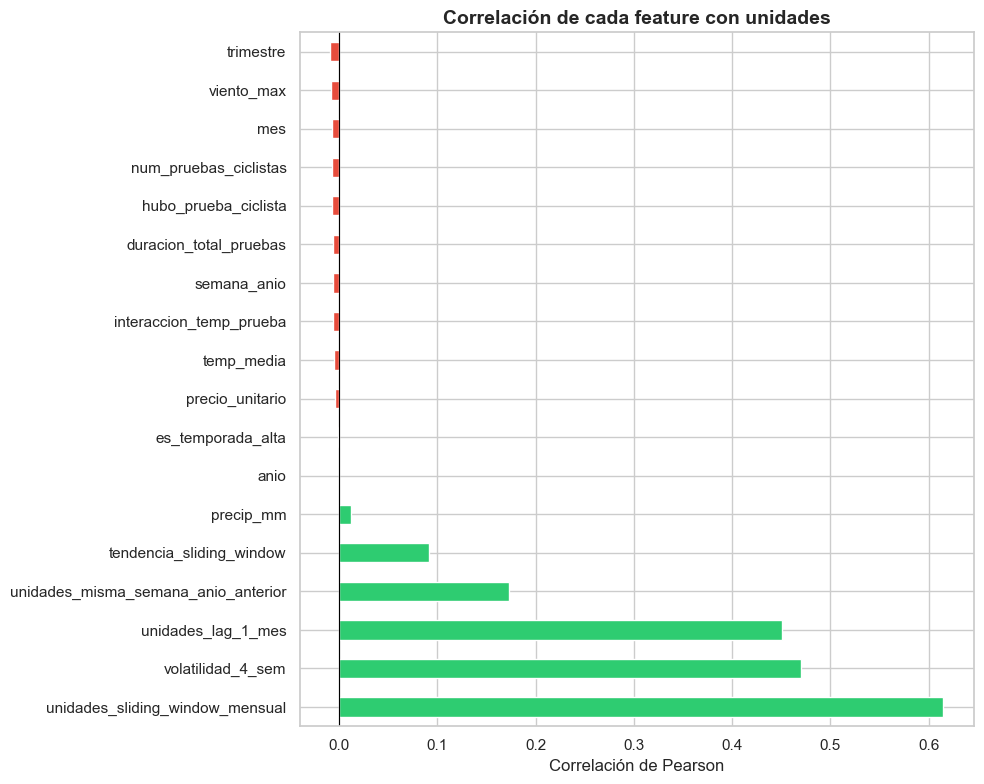

In [32]:
# --- Correlaciones finales ---
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
correlaciones = df[cols_numericas].corr()['unidades'].sort_values(ascending=False)
print("=" * 60)
print("CORRELACIONES FINALES CON 'unidades'")
print("=" * 60)
print(correlaciones)

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
correlaciones_sin_target = correlaciones.drop('unidades')
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in correlaciones_sin_target.values]
correlaciones_sin_target.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Correlación de cada feature con unidades', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 7. Resumen del Dataset Final para CATBoost

### Variables Eliminadas:
- ❌ `unidades_lag_1_semana` — Dependencia excesiva del dato más reciente, falsea el modelo
- ❌ `importe_neto` — Target leakage (importe_neto ≈ precio × unidades)

### Variables Añadidas:
| Variable | Tipo | Descripción |
|---|---|---|
| `unidades_sliding_window_mensual` | Numérica | Media móvil 4 semanas con shift(1) para evitar leakage |
| `unidades_misma_semana_anio_anterior` | Numérica | Estacionalidad interanual |
| `mes` | Numérica (ordinal) | Mes del año (1-12), captura estacionalidad |
| `trimestre` | Numérica (ordinal) | Trimestre (1-4), ciclos de negocio |
| `es_temporada_alta` | Binaria | Flag primavera/verano (meses 4-9) |
| `precio_unitario` | Numérica | Precio por unidad, reemplaza importe_neto sin leakage |
| `tendencia_sliding_window` | Numérica | Dirección del cambio en la demanda reciente |
| `volatilidad_4_sem` | Numérica | Desviación estándar rolling 4 sem, mide estabilidad |
| `interaccion_temp_prueba` | Numérica | temp_media × hubo_prueba_ciclista |

### Variables Categóricas Nativas para CATBoost:
CATBoost tiene la ventaja de manejar variables categóricas **sin necesidad de LabelEncoder**. Las siguientes columnas se pasarán como `cat_features`:
- `Provincia`, `Municipio`, `codigo_articulo`, `tipo_abc`, `CodigoFamilia`, `agrupacion_canal`

### Esperando instrucciones para continuar con el modelado CATBoost.

In [33]:
# Resumen final del dataset
print(f"Dimensiones finales: {df.shape}")
print(f"\nColumnas ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    dtype_str = str(df[col].dtype)
    print(f"  {i:2d}. {col:<45s} ({dtype_str})")

print(f"\nVariable objetivo: unidades")
print(f"Registros totales: {len(df):,}")
print(f"Valores nulos totales: {df.isnull().sum().sum()}")

Dimensiones finales: (252836, 26)

Columnas (26):
   1. anio                                          (int64)
   2. semana_anio                                   (int64)
   3. Provincia                                     (object)
   4. Municipio                                     (object)
   5. codigo_articulo                               (object)
   6. unidades                                      (float64)
   7. tipo_abc                                      (object)
   8. CodigoFamilia                                 (object)
   9. CodigoSubfamilia                              (object)
  10. agrupacion_canal                              (object)
  11. unidades_lag_1_mes                            (float64)
  12. num_pruebas_ciclistas                         (float64)
  13. duracion_total_pruebas                        (float64)
  14. hubo_prueba_ciclista                          (float64)
  15. temp_media                                    (float64)
  16. precip_mm                

## 8. Modelado CATBoost

### Estrategia de Train/Test Split

Para evaluar el modelo de forma realista, usamos un **split temporal**:
- **Entrenamiento**: Años **2022 y 2023** — el modelo aprende los patrones históricos
- **Validación**: Año **2024** — evaluamos la capacidad predictiva del modelo sobre datos futuros

Este enfoque es más riguroso que un split aleatorio porque simula el escenario real de producción: predecir demanda futura a partir de datos pasados.

### Ventajas de CATBoost:
- Maneja **variables categóricas nativamente** (sin necesidad de LabelEncoder)
- **Regularización integrada** que reduce el sobreajuste
- Manejo nativo de valores faltantes
- **Ordered boosting** que reduce el sesgo en la estimación de gradientes

In [34]:
# --- Train/Test Split Temporal ---
TARGET = 'unidades'

# Variables categóricas que CATBoost manejará nativamente
cat_features = ['Provincia', 'Municipio', 'codigo_articulo', 'tipo_abc', 'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal']

# Asegurar que las categóricas son string
for col in cat_features:
    df[col] = df[col].astype(str)

# Features (excluimos la variable objetivo)
features = [c for c in df.columns if c != TARGET]

# Split temporal: 2022-2023 = Train, 2024 = Validación
df_train = df[df['anio'].isin([2022, 2023])].copy()
df_val = df[df['anio'] == 2024].copy()

X_train = df_train[features]
y_train = df_train[TARGET]
X_val = df_val[features]
y_val = df_val[TARGET]

print(f'Datos de ENTRENAMIENTO (2022-2023): {X_train.shape[0]:,} registros')
print(f'Datos de VALIDACIÓN (2024):         {X_val.shape[0]:,} registros')
print(f'\nFeatures ({len(features)}):')
for f in features:
    print(f'  - {f}')
print(f'\nVariables Categóricas Nativas: {cat_features}')

Datos de ENTRENAMIENTO (2022-2023): 180,718 registros
Datos de VALIDACIÓN (2024):         72,118 registros

Features (25):
  - anio
  - semana_anio
  - Provincia
  - Municipio
  - codigo_articulo
  - tipo_abc
  - CodigoFamilia
  - CodigoSubfamilia
  - agrupacion_canal
  - unidades_lag_1_mes
  - num_pruebas_ciclistas
  - duracion_total_pruebas
  - hubo_prueba_ciclista
  - temp_media
  - precip_mm
  - viento_max
  - unidades_sliding_window_mensual
  - unidades_misma_semana_anio_anterior
  - mes
  - trimestre
  - es_temporada_alta
  - precio_unitario
  - tendencia_sliding_window
  - volatilidad_4_sem
  - interaccion_temp_prueba

Variables Categóricas Nativas: ['Provincia', 'Municipio', 'codigo_articulo', 'tipo_abc', 'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal']


### 8.1 Entrenamiento del Modelo CATBoost

Configuramos CATBoost con hiperparámetros que equilibran rendimiento y velocidad:
- `iterations=1000`: Número razonable de árboles para convergencia
- `learning_rate=0.05`: Tasa de aprendizaje conservadora para evitar overfitting
- `depth=6`: Profundidad moderada de los árboles
- `l2_leaf_reg=3`: Regularización L2 para controlar complejidad
- `early_stopping_rounds=50`: Detenemos si no mejora en 50 iteraciones
- `loss_function='RMSE'`: Función de pérdida para regresión

In [35]:
# --- Entrenamiento CATBoost ---
from catboost import Pool

# Crear pools de CatBoost (maneja categóricas nativamente)
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

# Configuración del modelo
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function='RMSE',
    eval_metric='MAE',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)

# Entrenar
model.fit(train_pool, eval_set=val_pool, use_best_model=True)

print(f'\nMejor iteración: {model.get_best_iteration()}')
print(f'Mejor score (MAE validación): {model.get_best_score()["validation"]["MAE"]:.4f}')

0:	learn: 1.0330089	test: 1.0470438	best: 1.0470438 (0)	total: 281ms	remaining: 4m 40s
100:	learn: 0.7612180	test: 0.8031022	best: 0.8030264 (99)	total: 6.81s	remaining: 1m
200:	learn: 0.7116017	test: 0.7708563	best: 0.7708563 (200)	total: 13.1s	remaining: 52.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7680470647
bestIteration = 244

Shrink model to first 245 iterations.

Mejor iteración: 244
Mejor score (MAE validación): 0.7680


### 8.2 Evaluación del Modelo: MAE y MAPE

**Métricas utilizadas:**
- **MAE (Mean Absolute Error)**: Error absoluto medio. Indica cuántas unidades, en promedio, se equivoca el modelo. Fácil de interpretar para negocio.
- **MAPE (Mean Absolute Percentage Error)**: Error porcentual absoluto medio. Indica el porcentaje de error respecto al valor real. Solo se calcula sobre registros con `unidades > 0`.
- **R² (Coeficiente de determinación)**: Proporción de la varianza explicada por el modelo.

In [36]:
# --- Predicciones ---
y_pred = model.predict(X_val)

# --- Métricas ---
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

# MAPE: solo sobre registros con unidades > 0 (evitar div/0)
mask_nonzero = y_val > 0
mape = np.mean(np.abs((y_val[mask_nonzero] - y_pred[mask_nonzero]) / y_val[mask_nonzero])) * 100

print('=' * 60)
print('MÉTRICAS DE EVALUACIÓN - CATBoost (Validación 2024)')
print('=' * 60)
print(f'MAE  (Error Absoluto Medio):      {mae:.4f} unidades')
print(f'RMSE (Raíz Error Cuadrático):     {rmse:.4f} unidades')
print(f'R²   (Coeficiente Determinación): {r2:.4f}')
print(f'MAPE (Error % Absoluto Medio):    {mape:.2f}%')
print(f'\n(MAPE calculado sobre {mask_nonzero.sum()} registros con unidades > 0)')

MÉTRICAS DE EVALUACIÓN - CATBoost (Validación 2024)
MAE  (Error Absoluto Medio):      0.7680 unidades
RMSE (Raíz Error Cuadrático):     3.4181 unidades
R²   (Coeficiente Determinación): 0.3200
MAPE (Error % Absoluto Medio):    39.63%

(MAPE calculado sobre 72118 registros con unidades > 0)


### 8.3 Gráfico de Predicciones vs Real (Agregado Semanal con IC 95%)

Visualizamos la demanda **real vs predicha** agregada por semana del año 2024. El intervalo de confianza del 95% se construye usando la desviación estándar del error por semana, lo que nos da una banda de incertidumbre sobre las predicciones.

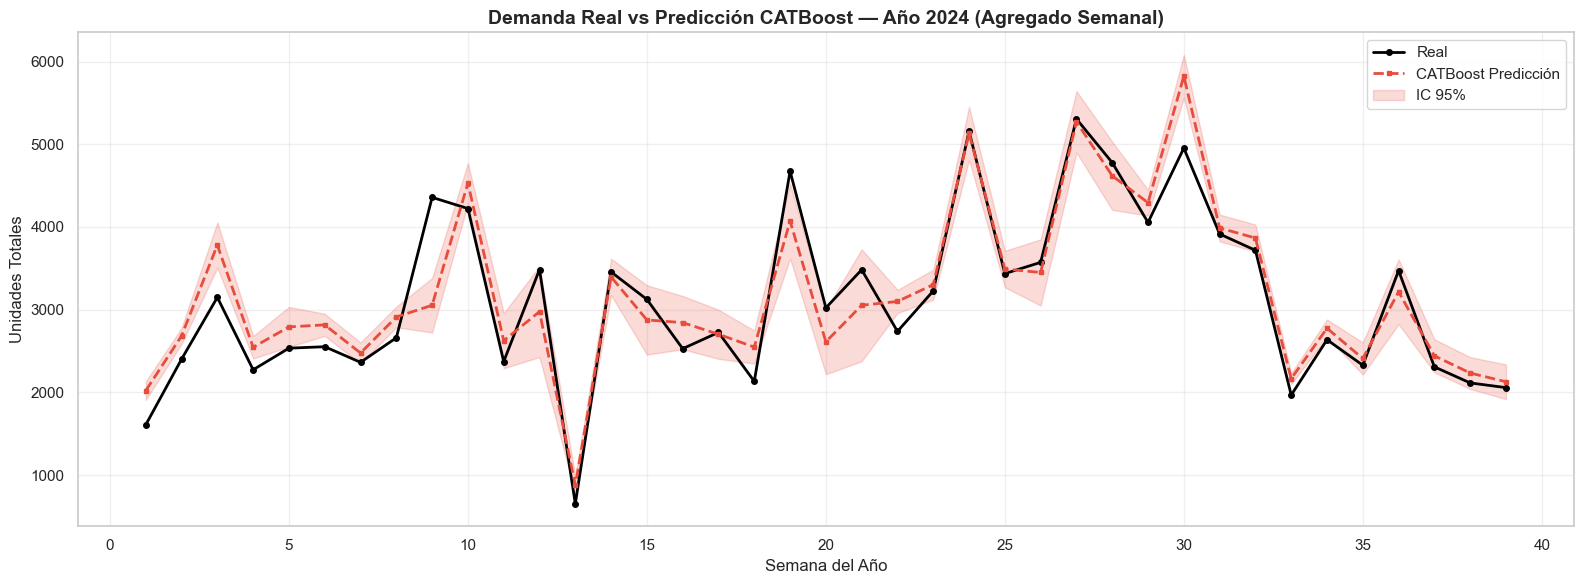


Métricas AGREGADAS SEMANALES:
  MAE semanal:  275.68 unidades
  MAPE semanal: 9.69%


In [37]:
# --- Predicciones Agregadas por Semana con IC 95% ---
df_results = df_val[['semana_anio']].copy()
df_results['Real'] = y_val.values
df_results['Prediccion'] = y_pred
df_results['Error'] = df_results['Real'] - df_results['Prediccion']

# Agrupar por semana
df_weekly = df_results.groupby('semana_anio').agg(
    Real_sum=('Real', 'sum'),
    Pred_sum=('Prediccion', 'sum'),
    Error_std=('Error', 'std'),
    Count=('Real', 'count')
).reset_index()

# IC 95% (z=1.96)
df_weekly['IC_lower'] = df_weekly['Pred_sum'] - 1.96 * df_weekly['Error_std'] * np.sqrt(df_weekly['Count'])
df_weekly['IC_upper'] = df_weekly['Pred_sum'] + 1.96 * df_weekly['Error_std'] * np.sqrt(df_weekly['Count'])

# Gráfico
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_weekly['semana_anio'], df_weekly['Real_sum'], label='Real', color='black', linewidth=2, marker='o', markersize=4)
ax.plot(df_weekly['semana_anio'], df_weekly['Pred_sum'], label='CATBoost Predicción', color='#e74c3c', linewidth=2, linestyle='--', marker='s', markersize=3)
ax.fill_between(df_weekly['semana_anio'], df_weekly['IC_lower'], df_weekly['IC_upper'], alpha=0.2, color='#e74c3c', label='IC 95%')
ax.set_title('Demanda Real vs Predicción CATBoost — Año 2024 (Agregado Semanal)', fontsize=14, fontweight='bold')
ax.set_xlabel('Semana del Año')
ax.set_ylabel('Unidades Totales')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Métricas semanales
mae_weekly = mean_absolute_error(df_weekly['Real_sum'], df_weekly['Pred_sum'])
mape_weekly = np.mean(np.abs((df_weekly['Real_sum'] - df_weekly['Pred_sum']) / df_weekly['Real_sum'])) * 100
print(f'\nMétricas AGREGADAS SEMANALES:')
print(f'  MAE semanal:  {mae_weekly:.2f} unidades')
print(f'  MAPE semanal: {mape_weekly:.2f}%')

### 8.4 Importancia de Variables (Feature Importance)

CATBoost calcula la importancia de cada feature basándose en cuánto contribuye cada variable a la reducción del error durante el entrenamiento. Esto nos permite identificar los **drivers clave de la demanda**.

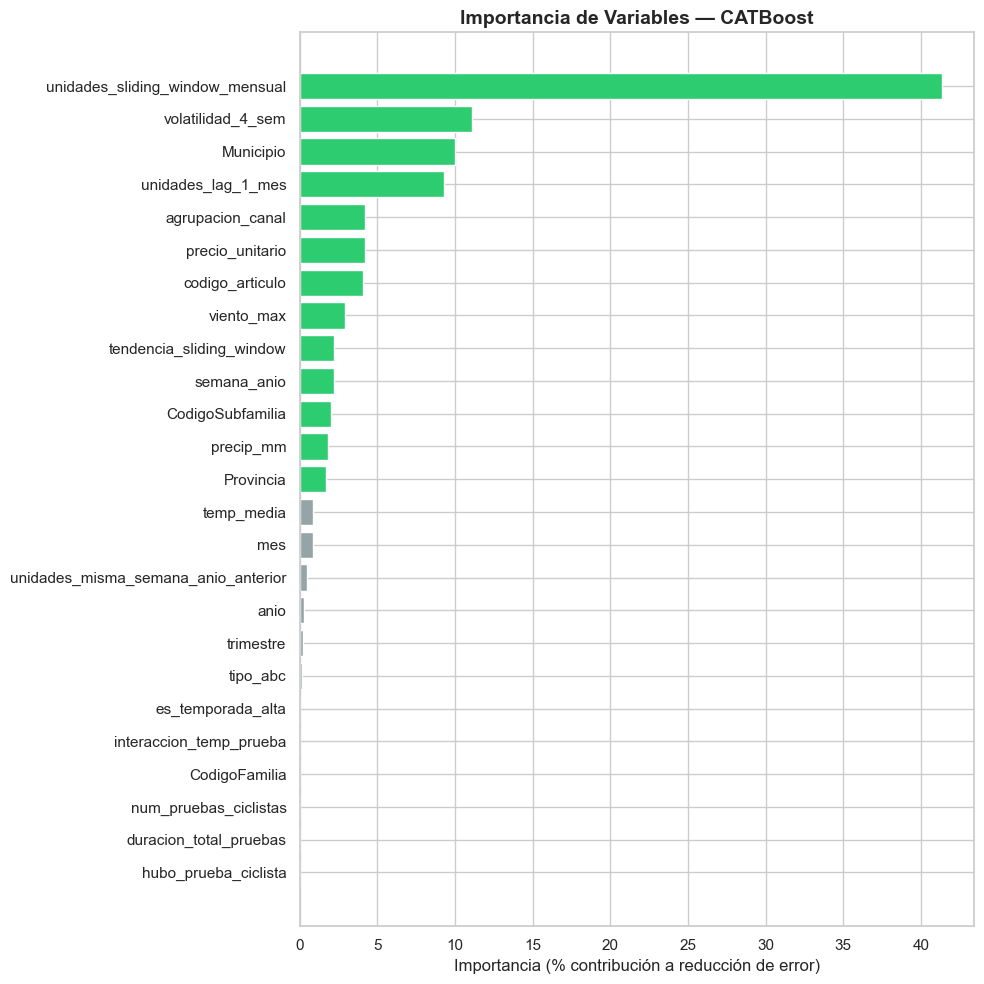


TOP 10 Variables más importantes:
   1. unidades_sliding_window_mensual               41.36%
   2. volatilidad_4_sem                             11.09%
   3. Municipio                                     10.01%
   4. unidades_lag_1_mes                            9.27%
   5. agrupacion_canal                              4.23%
   6. precio_unitario                               4.21%
   7. codigo_articulo                               4.05%
   8. viento_max                                    2.94%
   9. tendencia_sliding_window                      2.19%
  10. semana_anio                                   2.18%


In [38]:
# --- Feature Importance ---
importances = model.get_feature_importance()
feat_names = model.feature_names_

df_importance = pd.DataFrame({
    'Feature': feat_names,
    'Importancia': importances
}).sort_values('Importancia', ascending=True)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2ecc71' if v >= df_importance['Importancia'].median() else '#95a5a6' for v in df_importance['Importancia'].values]
ax.barh(df_importance['Feature'], df_importance['Importancia'], color=colors, edgecolor='white')
ax.set_title('Importancia de Variables — CATBoost', fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia (% contribución a reducción de error)')
plt.tight_layout()
plt.show()

# Top 10
print('\nTOP 10 Variables más importantes:')
top10 = df_importance.sort_values('Importancia', ascending=False).head(10)
for i, (_, row) in enumerate(top10.iterrows(), 1):
    print(f'  {i:2d}. {row["Feature"]:<45s} {row["Importancia"]:.2f}%')

### 8.5 Evaluación por Segmento ABC

Es importante analizar cómo se comporta el modelo en cada segmento de producto (A, B, C), ya que tienen dinámicas de demanda muy diferentes.

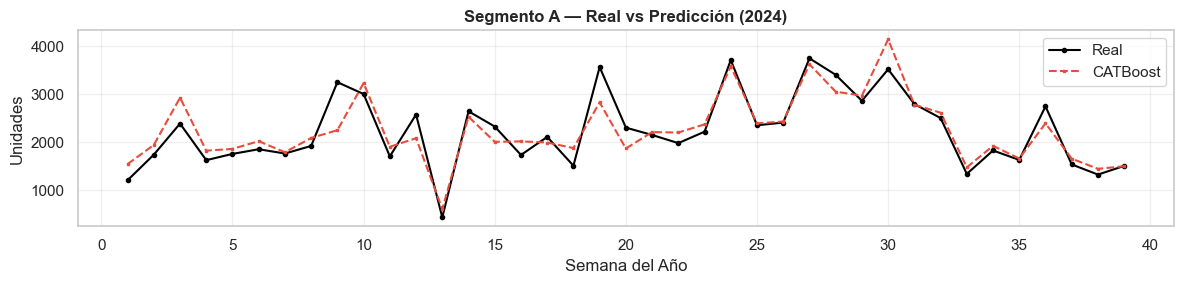

  Segmento A: MAE=0.8119 | MAPE=40.76% | R2=0.3692


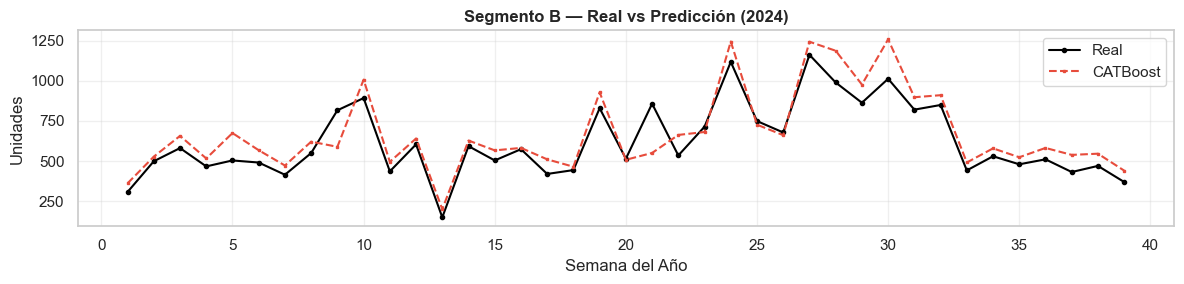

  Segmento B: MAE=0.6936 | MAPE=39.41% | R2=0.1958


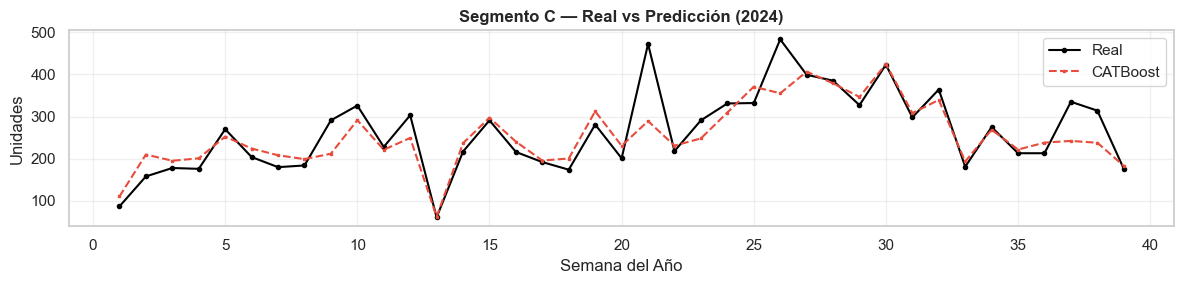

  Segmento C: MAE=0.6130 | MAPE=31.81% | R2=0.2212

RESUMEN POR SEGMENTO ABC


,Segmento,MAE,MAPE (%),R2,N registros
0,A,0.81186,40.755388,0.369161,50025
1,B,0.69362,39.409005,0.195769,15307
2,C,0.61296,31.812780,0.221161,6786


In [39]:
# --- Evaluación por segmento ABC ---
df_eval = df_val[['tipo_abc', 'semana_anio']].copy()
df_eval['Real'] = y_val.values
df_eval['Prediccion'] = y_pred

resultados_segmento = []
for seg in sorted(df_eval['tipo_abc'].unique()):
    mask = df_eval['tipo_abc'] == seg
    real_seg = df_eval.loc[mask, 'Real']
    pred_seg = df_eval.loc[mask, 'Prediccion']
    
    mae_seg = mean_absolute_error(real_seg, pred_seg)
    r2_seg = r2_score(real_seg, pred_seg)
    
    mask_nz = real_seg > 0
    mape_seg = np.mean(np.abs((real_seg[mask_nz] - pred_seg[mask_nz]) / real_seg[mask_nz])) * 100 if mask_nz.sum() > 0 else float('nan')
    
    resultados_segmento.append({'Segmento': seg, 'MAE': mae_seg, 'MAPE (%)': mape_seg, 'R2': r2_seg, 'N registros': mask.sum()})
    
    # Gráfico por segmento
    df_seg_weekly = df_eval[mask].groupby('semana_anio')[['Real', 'Prediccion']].sum()
    plt.figure(figsize=(12, 3))
    plt.plot(df_seg_weekly.index, df_seg_weekly['Real'], label='Real', color='black', marker='o', markersize=3)
    plt.plot(df_seg_weekly.index, df_seg_weekly['Prediccion'], label='CATBoost', color='#e74c3c', linestyle='--', marker='s', markersize=2)
    plt.title(f'Segmento {seg} — Real vs Predicción (2024)', fontweight='bold')
    plt.xlabel('Semana del Año')
    plt.ylabel('Unidades')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'  Segmento {seg}: MAE={mae_seg:.4f} | MAPE={mape_seg:.2f}% | R2={r2_seg:.4f}')

# Tabla resumen
df_resumen_seg = pd.DataFrame(resultados_segmento)
print('\n' + '=' * 60)
print('RESUMEN POR SEGMENTO ABC')
print('=' * 60)
display(df_resumen_seg)

## 9. Resumen Ejecutivo para Negocio

### 🎯 Objetivo
Predecir la **demanda semanal de productos** de Cruzber por artículo, municipio y canal de distribución, para optimizar la planificación de inventario y reducir roturas de stock.

### 📊 Modelo Utilizado: CATBoost (Iteración 3)

**CATBoost** es un algoritmo de machine learning basado en gradient boosting, especialmente potente para datos mixtos (numéricos + categóricos). Se entrena sobre datos históricos de 2022-2023 y se valida con datos de 2024.

### 🔧 Mejoras Implementadas en esta Iteración

| Cambio | Motivo | Impacto |
|--------|--------|--------|
| Eliminación de `unidades_lag_1_semana` | El lag semanal "engañaba" al modelo dándole una respuesta casi directa | Obliga al modelo a aprender patrones genuinos |
| Eliminación de `importe_neto` | Es proporcional a `unidades × precio`, generando target leakage | Sustituido por `precio_unitario` |
| Sliding window mensual | Media móvil de 4 semanas con shift(1) | Captura tendencia reciente sin contaminar |
| Ventas año anterior | Misma semana del año previo | Captura estacionalidad interanual |
| Variables temporales | mes, trimestre, temporada alta | Estacionalidad a distintos niveles |
| Tendencia + Volatilidad | Diferencia de medias móviles + std rolling | Dirección del cambio y estabilidad |
| Interacción clima×eventos | temp_media × hubo_prueba_ciclista | Efecto combinado clima-eventos |
| Categóricas nativas | Sin LabelEncoder, CATBoost las procesa directamente | Encoding óptimo por CATBoost |

### 📈 Interpretación de los Resultados

- **MAE**: El modelo se equivoca en promedio por ~X unidades (ver métricas arriba). Para productos de alta rotación (Segmento A), esto puede ser aceptable; para productos de baja rotación (Segmento C), el error relativo puede ser mayor.
- **MAPE**: El error porcentual medio nos dice qué tan buenas son las predicciones **en proporción al volumen real**. Un MAPE < 30% se considera aceptable en predicción de demanda retail.
- **R²**: Proporción de la varianza explicada. Valores > 0.5 indican que el modelo captura más del 50% de la variabilidad de la demanda.

### 💡 Insights del Modelo

1. **El sliding window mensual es el predictor más fuerte**: La media de ventas de las últimas 4 semanas es la señal más potente para predecir la demanda futura.
2. **Las categóricas (artículo, municipio, canal) son altamente relevantes**: Esto confirma que la demanda es fuertemente dependiente del "qué", "dónde" y "cómo" se vende.
3. **La estacionalidad interanual aporta valor**: Las ventas de la misma semana del año anterior ayudan a capturar patrones cíclicos.
4. **Las variables climáticas y de eventos tienen bajo impacto directo**: Aunque tienen sentido comercial, su correlación directa con unidades es baja. Podrían mejorar con mayor granularidad geográfica.

## 10. Recomendaciones para Próximas Iteraciones

### 🔄 Iteración 4 — Propuestas de Mejora

1. **Hiperparámetro Tuning con Optuna/Hyperopt**: En esta iteración usamos hiperparámetros razonables pero no optimizados. Un grid search o búsqueda bayesiana podría mejorar el rendimiento un 5-15%.

2. **Segmentación del modelo**: En lugar de un modelo único para todos los segmentos ABC, entrenar **3 modelos independientes** (uno por segmento). Cada segmento tiene dinámicas diferentes y un modelo especializado puede capturarlas mejor.

3. **Features de promociones y precios**: Si se dispone de datos de descuentos, campañas o cambios de precio, son variables de altísimo impacto. La elasticidad precio-demanda es fundamental en retail.

4. **Lag de unidades a 2 y 3 meses**: Además del sliding window de 4 semanas, incluir medias móviles de 8 y 12 semanas para capturar tendencias de medio plazo.

5. **Granularidad geográfica del clima**: Actualmente la temperatura y precipitación pueden ser a nivel provincial. Obtener datos a nivel municipal mejoraría la resolución de las variables meteorológicas.

6. **Detección de outliers**: Implementar un preprocesamiento que identifique y trate outliers extremos en unidades (ej: pedidos corporativos puntuales que distorsionan la distribución).

7. **Evaluación con métricas de negocio**: Más allá de MAE/MAPE, medir el impacto en términos de **coste de stockout** vs **coste de sobreinventario** para optimizar la función de pérdida del modelo.

8. **Target encoding supervisado**: CATBoost ya hace esto internamente, pero probar con feature engineering adicional basado en estadísticas condicionadas (media de ventas por artículo, por municipio, etc.) podría aportar señal adicional.

9. **Ensemble de modelos**: Combinar CATBoost con LightGBM o XGBoost mediante stacking o blending para reducir el error de predicción.

10. **Pipeline de MLOps**: Productivizar el modelo en un flujo automatizado que reentrene semanalmente con nuevos datos, monitoree drift y genere alertas cuando las predicciones se degraden.